In [ ]:
#Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/codamd.csv')

In [ ]:
df.head()

,codanum,focal,whale,codatype,Duration,handv
0,4933,True,ATWOOD,1+1+3,0.898250,i
1,4934,True,ATWOOD,1+1+3,0.865575,i
2,4935,True,ATWOOD,1+1+3,0.858317,i
3,4936,True,ATWOOD,1+1+3,0.861942,i
4,4937,True,ATWOOD,1+1+3,0.838825,i


In [ ]:
#Program to print all the column names of the dataframe
list(df.columns)

['codanum', 'focal', 'whale', 'codatype', 'Duration', 'handv']

In [ ]:
#Identify the data types for all the variables in the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1375 entries, 0 to 1374
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   codanum   1375 non-null   int64  
 1   focal     1375 non-null   bool   
 2   whale     1267 non-null   object 
 3   codatype  1375 non-null   object 
 4   Duration  1375 non-null   float64
 5   handv     1142 non-null   object 
dtypes: bool(1), float64(1), int64(1), object(3)
memory usage: 55.2+ KB


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1375, 6)


In [ ]:
print("\nColumns available:")
print(df.columns.tolist())


Columns available:
['codanum', 'focal', 'whale', 'codatype', 'Duration', 'handv']


In [ ]:
print("\nTarget Distribution:")
print(df['handv'].value_counts())


Target Distribution:
handv
a    745
i    397
Name: count, dtype: int64


In [ ]:
df_clean = df.dropna(subset=['handv']).copy()

In [ ]:
df_clean.isnull().sum()

,0
codanum,0
focal,0
whale,0
codatype,0
Duration,0
handv,0


In [ ]:
print("Unique values in 'handv':")
print(df_clean['handv'].unique())

Unique values in 'handv':
['i' 'a']


In [ ]:
print("\nUnique values in 'codatype':")
print(df_clean['codatype'].unique())
print(f"Total number of unique coda types: {df_clean['codatype'].nunique()}")


Unique values in 'codatype':
['1+1+3' '6-NOISE' '9i' '8i' '5R1' '6i' '5-NOISE' '8D' '10R' '7D2'
 '9-NOISE' '10i' '4-NOISE' '7-NOISE' '10-NOISE' '4R2' '5R3' '5R2' '7i'
 '2+3' '3D' '8R' '9R']
Total number of unique coda types: 23


In [ ]:
# 1. Initialize the LabelEncoder
le = LabelEncoder()

# 2. Fit and transform the 'handv' column into numbers
df_clean['handv_encoded'] = le.fit_transform(df_clean['handv'])

print("\nFirst 5 rows of our new column:")
print(df_clean[['handv', 'handv_encoded']].head())


First 5 rows of our new column:
  handv  handv_encoded
0     i              1
1     i              1
2     i              1
3     i              1
4     i              1


In [ ]:
# 2. Check unique values in our new encoded target column
print("\nUnique values in 'handv_encoded':")
print(df_clean['handv_encoded'].unique())


Unique values in 'handv_encoded':
[1 0]


In [ ]:
df_clean['focal_encoded'] = df_clean['focal'].astype(int)
# Verify the conversion by looking at the original and the new column
print(df_clean[['focal', 'focal_encoded']].head())

   focal  focal_encoded
0   True              1
1   True              1
2   True              1
3   True              1
4   True              1


In [ ]:
# 1. Select the raw columns we want to use as features
features_raw = df_clean[['Duration', 'focal_encoded', 'codatype', 'whale']]

# 2. One-Hot Encode 'codatype' and 'whale' at the same time
# drop_first=True drops one column per category to avoid the dummy variable trap
# dtype=int changes the output from True/False to clean 1/0 integers
X = pd.get_dummies(features_raw, columns=['codatype', 'whale'], drop_first=True, dtype=int)

# 3. Check the shape to see how many columns we have now
print("New Features Matrix (X) Shape:", X.shape)
print("\nFirst 3 rows of your fully engineered features:")
X.head(3)

New Features Matrix (X) Shape: (1142, 36)

First 3 rows of your fully engineered features:


,Duration,focal_encoded,codatype_10-NOISE,codatype_10R,codatype_10i,codatype_2+3,codatype_3D,codatype_4-NOISE,codatype_4R2,codatype_5-NOISE,...,whale_JOCASTA,whale_LADYO,whale_LAIUS,whale_NALGENE,whale_PINCHY,whale_SAM,whale_SOPH,whale_SOURSOP,whale_TBB,whale_TWEAK
0,0.898250,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.865575,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.858317,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1142 entries, 0 to 1374
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Duration           1142 non-null   float64
 1   focal_encoded      1142 non-null   int64  
 2   codatype_10-NOISE  1142 non-null   int64  
 3   codatype_10R       1142 non-null   int64  
 4   codatype_10i       1142 non-null   int64  
 5   codatype_2+3       1142 non-null   int64  
 6   codatype_3D        1142 non-null   int64  
 7   codatype_4-NOISE   1142 non-null   int64  
 8   codatype_4R2       1142 non-null   int64  
 9   codatype_5-NOISE   1142 non-null   int64  
 10  codatype_5R1       1142 non-null   int64  
 11  codatype_5R2       1142 non-null   int64  
 12  codatype_5R3       1142 non-null   int64  
 13  codatype_6-NOISE   1142 non-null   int64  
 14  codatype_6i        1142 non-null   int64  
 15  codatype_7-NOISE   1142 non-null   int64  
 16  codatype_7D2       1142 non-n

In [ ]:
# 1. Calculate the 25th and 75th percentiles of Duration
Q1 = df_clean['Duration'].quantile(0.25)
Q3 = df_clean['Duration'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define bounds for outliers (anything beyond 1.5 * IQR is an outlier)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Find the anomalies
outliers = df_clean[(df_clean['Duration'] < lower_bound) | (df_clean['Duration'] > upper_bound)]

print(f"--- Duration Statistics ---")
print(f"Minimum Duration: {df_clean['Duration'].min()} seconds")
print(f"Maximum Duration: {df_clean['Duration'].max()} seconds")
print(f"Lower Bound for Outliers: {lower_bound:.4f} seconds")
print(f"Upper Bound for Outliers: {upper_bound:.4f} seconds")
print(f"Total number of outlier rows found: {len(outliers)}")

--- Duration Statistics ---
Minimum Duration: 0.2175083 seconds
Maximum Duration: 1.9095 seconds
Lower Bound for Outliers: -0.8093 seconds
Upper Bound for Outliers: 2.4741 seconds
Total number of outlier rows found: 0


In [ ]:
X.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Duration,1142.0,0.894877,0.399459,0.217508,0.421956,0.986196,1.242804,1.9095
focal_encoded,1142.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.0000
codatype_10-NOISE,1142.0,0.000876,0.029591,0.000000,0.000000,0.000000,0.000000,1.0000
codatype_10R,1142.0,0.002627,0.051209,0.000000,0.000000,0.000000,0.000000,1.0000
codatype_10i,1142.0,0.003503,0.059105,0.000000,0.000000,0.000000,0.000000,1.0000
codatype_2+3,1142.0,0.001751,0.041830,0.000000,0.000000,0.000000,0.000000,1.0000
codatype_3D,1142.0,0.006130,0.078086,0.000000,0.000000,0.000000,0.000000,1.0000
codatype_4-NOISE,1142.0,0.003503,0.059105,0.000000,0.000000,0.000000,0.000000,1.0000
codatype_4R2,1142.0,0.010508,0.102013,0.000000,0.000000,0.000000,0.000000,1.0000
codatype_5-NOISE,1142.0,0.009632,0.097713,0.000000,0.000000,0.000000,0.000000,1.0000


In [ ]:
# 1. Grab your clean, encoded target (the answers)
y = df_clean['handv_encoded']

# 2. Save the features matrix (X) to its own CSV file
X.to_csv('Prepared_final_Whale_Features.csv', index=False)

# 3. Save the target vector (y) to its own CSV file
y.to_csv('Prepared_final_Whale_Targets.csv', index=False)

print("--- Both Dataframes Saved Separately! ---")
print(f"Features saved to: 'Prepared_final_Whale_Features.csv' (Shape: {X.shape})")
print(f"Targets saved to:  'Prepared_final_Whale_Targets.csv'  (Shape: {y.shape})")

--- Both Dataframes Saved Separately! ---
Features saved to: 'Prepared_final_Whale_Features.csv' (Shape: (1142, 36))
Targets saved to:  'Prepared_final_Whale_Targets.csv'  (Shape: (1142,))


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# 1. Load X and y directly from the separate CSV files you just saved
X = pd.read_csv('/content/Prepared_final_Whale_Features.csv')
y = pd.read_csv('/content/Prepared_final_Whale_Targets.csv').squeeze()# Run the split on our strictly separated X and y

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n--- Train-Test Split Complete ---")
print(f"Rows for Training: {X_train.shape[0]}")
print(f"Rows for Testing:  {X_test.shape[0]}")


--- Train-Test Split Complete ---
Rows for Training: 913
Rows for Testing:  229


In [ ]:
# Check the exact count of each vowel in your training set
print("Training set class balance:")
print(y_train.value_counts())

print("\nTraining set percentages:")
print(y_train.value_counts(normalize=True) * 180 / 1.8) # Quick way to show percentages

Training set class balance:
handv_encoded
0    596
1    317
Name: count, dtype: int64

Training set percentages:
handv_encoded
0    65.279299
1    34.720701
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

=== RANDOM FOREST PERFORMANCE ===
Accuracy Score: 0.7424
F1-Score:       0.6380

--- Classification Report ---
              precision    recall  f1-score   support

 Vowel_0 (a)       0.81      0.79      0.80       149
 Vowel_1 (i)       0.63      0.65      0.64        80

    accuracy                           0.74       229
   macro avg       0.72      0.72      0.72       229
weighted avg       0.74      0.74      0.74       229



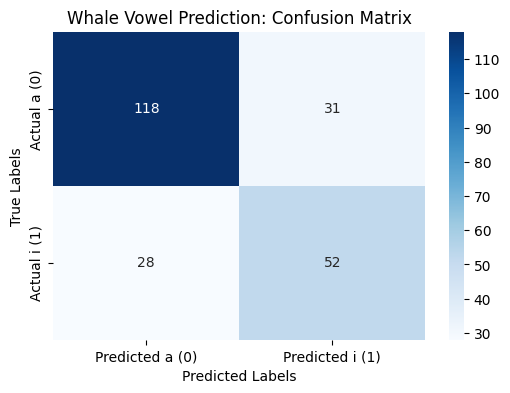

In [ ]:
# 1. Initialize and Train the Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 2. Make predictions on the Test Data
y_pred = rf_model.predict(X_test)

# 3. Calculate Core Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== RANDOM FOREST PERFORMANCE ===")
print(f"Accuracy Score: {accuracy:.4f}")
print(f"F1-Score:       {f1:.4f}\n")

# 4. Print Detailed Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Vowel_0 (a)', 'Vowel_1 (i)']))

# 5. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted a (0)', 'Predicted i (1)'],
            yticklabels=['Actual a (0)', 'Actual i (1)'])
plt.title('Whale Vowel Prediction: Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

=== DECISION TREE PERFORMANCE ===
Accuracy Score: 0.7380
F1-Score:       0.6296

              precision    recall  f1-score   support

 Vowel_0 (a)       0.80      0.79      0.80       149
 Vowel_1 (i)       0.62      0.64      0.63        80

    accuracy                           0.74       229
   macro avg       0.71      0.71      0.71       229
weighted avg       0.74      0.74      0.74       229



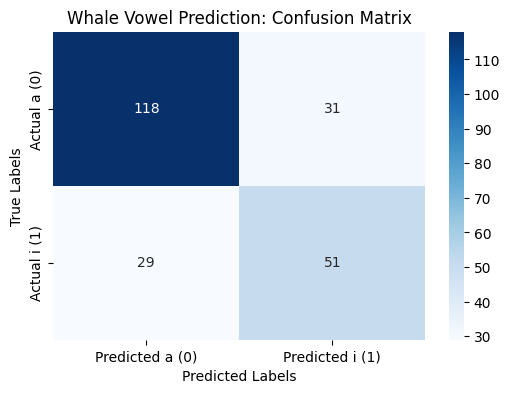

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 1. Initialize and Train the Decision Tree
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

# 2. Predict on the Test Data
y_pred_dt = dt_model.predict(X_test)

# 3. Print Results
print("=== DECISION TREE PERFORMANCE ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score:       {f1_score(y_test, y_pred_dt):.4f}\n")
print(classification_report(y_test, y_pred_dt, target_names=['Vowel_0 (a)', 'Vowel_1 (i)']))

# 5. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted a (0)', 'Predicted i (1)'],
            yticklabels=['Actual a (0)', 'Actual i (1)'])
plt.title('Whale Vowel Prediction: Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

=== LOGISTIC REGRESSION PERFORMANCE ===
Accuracy Score: 0.6638
F1-Score:       0.6516

--- Classification Report ---
              precision    recall  f1-score   support

 Vowel_0 (a)       0.91      0.54      0.68       149
 Vowel_1 (i)       0.51      0.90      0.65        80

    accuracy                           0.66       229
   macro avg       0.71      0.72      0.66       229
weighted avg       0.77      0.66      0.67       229



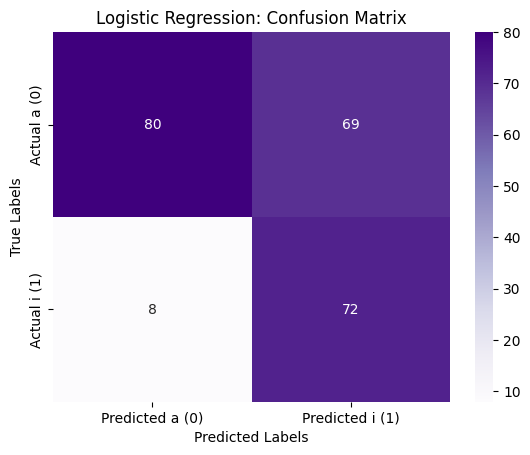

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 1. Initialize and Train Logistic Regression
# max_iter=1000 ensures the solver has enough iterations to converge
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# 2. Predict on the Test Data
y_pred_lr = lr_model.predict(X_test)

# 3. Print Performance Metrics
print("=== LOGISTIC REGRESSION PERFORMANCE ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:       {f1_score(y_test, y_pred_lr):.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred_lr, target_names=['Vowel_0 (a)', 'Vowel_1 (i)']))

# 4. Generate and Save the Confusion Matrix Plot
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted a (0)', 'Predicted i (1)'],
            yticklabels=['Actual a (0)', 'Actual i (1)'])

plt.title('Logistic Regression: Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Saves the plot image to your local Colab environment workspace
plt.savefig('logistic_regression_confusion_matrix.png', bbox_inches='tight')

=== HARD VOTING PERFORMANCE ===
Accuracy: 0.7336 | F1-Score: 0.6065
              precision    recall  f1-score   support

 Vowel_0 (a)       0.79      0.81      0.80       149
 Vowel_1 (i)       0.63      0.59      0.61        80

    accuracy                           0.73       229
   macro avg       0.71      0.70      0.70       229
weighted avg       0.73      0.73      0.73       229


=== SOFT VOTING PERFORMANCE ===
Accuracy: 0.7598 | F1-Score: 0.6667
              precision    recall  f1-score   support

 Vowel_0 (a)       0.83      0.80      0.81       149
 Vowel_1 (i)       0.65      0.69      0.67        80

    accuracy                           0.76       229
   macro avg       0.74      0.74      0.74       229
weighted avg       0.76      0.76      0.76       229



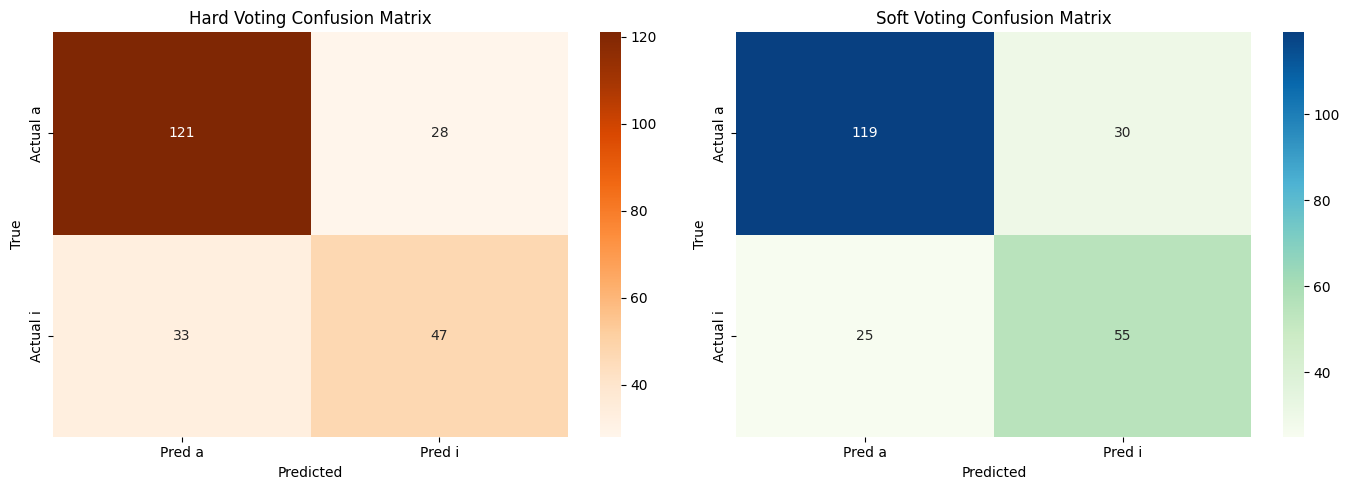

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 1. Initialize the base models
base_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
base_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. Build both Hard and Soft Voting ensembles
voting_hard = VotingClassifier(estimators=[('lr', base_lr), ('rf', base_rf)], voting='hard')
voting_soft = VotingClassifier(estimators=[('lr', base_lr), ('rf', base_rf)], voting='soft')

# 3. Fit both models
voting_hard.fit(X_train, y_train)
voting_soft.fit(X_train, y_train)

# 4. Generate predictions
preds_hard = voting_hard.predict(X_test)
preds_soft = voting_soft.predict(X_test)

# --- Print Reports ---
print("=== HARD VOTING PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(y_test, preds_hard):.4f} | F1-Score: {f1_score(y_test, preds_hard):.4f}")
print(classification_report(y_test, preds_hard, target_names=['Vowel_0 (a)', 'Vowel_1 (i)']))

print("\n=== SOFT VOTING PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(y_test, preds_soft):.4f} | F1-Score: {f1_score(y_test, preds_soft):.4f}")
print(classification_report(y_test, preds_soft, target_names=['Vowel_0 (a)', 'Vowel_1 (i)']))

# 5. Plot Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hard Voting CM
cm_hard = confusion_matrix(y_test, preds_hard)
sns.heatmap(cm_hard, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Pred a', 'Pred i'], yticklabels=['Actual a', 'Actual i'])
axes[0].set_title('Hard Voting Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Soft Voting CM (Fixed colormap to 'GnBu')
cm_soft = confusion_matrix(y_test, preds_soft)
sns.heatmap(cm_soft, annot=True, fmt='d', cmap='GnBu', ax=axes[1],
            xticklabels=['Pred a', 'Pred i'], yticklabels=['Actual a', 'Actual i'])
axes[1].set_title('Soft Voting Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

=== NEW: HARD VOTING (LR + DT) PERFORMANCE ===
Accuracy: 0.7293 | F1-Score: 0.5974
              precision    recall  f1-score   support

 Vowel_0 (a)       0.78      0.81      0.80       149
 Vowel_1 (i)       0.62      0.57      0.60        80

    accuracy                           0.73       229
   macro avg       0.70      0.69      0.70       229
weighted avg       0.73      0.73      0.73       229


=== NEW: SOFT VOTING (LR + DT) PERFORMANCE ===
Accuracy: 0.7380 | F1-Score: 0.6296
              precision    recall  f1-score   support

 Vowel_0 (a)       0.80      0.79      0.80       149
 Vowel_1 (i)       0.62      0.64      0.63        80

    accuracy                           0.74       229
   macro avg       0.71      0.71      0.71       229
weighted avg       0.74      0.74      0.74       229



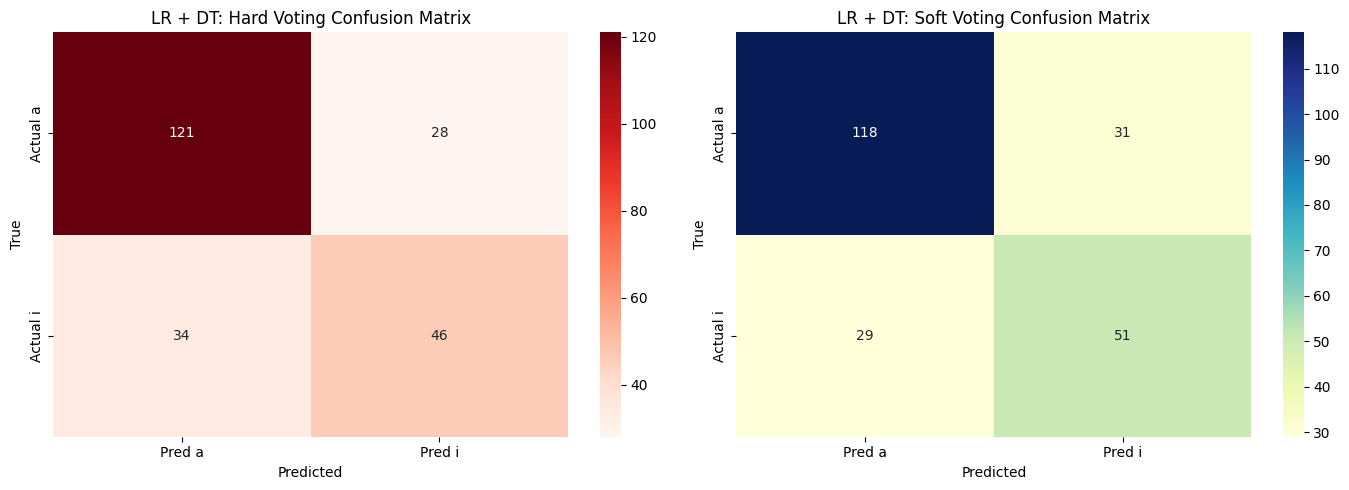

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 1. Initialize the new base model duo
base_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
base_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# 2. Build both Hard and Soft Voting ensembles with the Decision Tree
voting_hard_dt = VotingClassifier(estimators=[('lr', base_lr), ('dt', base_dt)], voting='hard')
voting_soft_dt = VotingClassifier(estimators=[('lr', base_lr), ('dt', base_dt)], voting='soft')

# 3. Fit both new models
voting_hard_dt.fit(X_train, y_train)
voting_soft_dt.fit(X_train, y_train)

# 4. Generate predictions
preds_hard_dt = voting_hard_dt.predict(X_test)
preds_soft_dt = voting_soft_dt.predict(X_test)

# --- Print Reports ---
print("=== NEW: HARD VOTING (LR + DT) PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(y_test, preds_hard_dt):.4f} | F1-Score: {f1_score(y_test, preds_hard_dt):.4f}")
print(classification_report(y_test, preds_hard_dt, target_names=['Vowel_0 (a)', 'Vowel_1 (i)']))

print("\n=== NEW: SOFT VOTING (LR + DT) PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(y_test, preds_soft_dt):.4f} | F1-Score: {f1_score(y_test, preds_soft_dt):.4f}")
print(classification_report(y_test, preds_soft_dt, target_names=['Vowel_0 (a)', 'Vowel_1 (i)']))

# 5. Plot Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hard Voting CM
cm_hard_dt = confusion_matrix(y_test, preds_hard_dt)
sns.heatmap(cm_hard_dt, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Pred a', 'Pred i'], yticklabels=['Actual a', 'Actual i'])
axes[0].set_title('LR + DT: Hard Voting Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Soft Voting CM
cm_soft_dt = confusion_matrix(y_test, preds_soft_dt)
sns.heatmap(cm_soft_dt, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1],
            xticklabels=['Pred a', 'Pred i'], yticklabels=['Actual a', 'Actual i'])
axes[1].set_title('LR + DT: Soft Voting Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

=== NEW: HARD VOTING (DT + RF) PERFORMANCE ===
Accuracy: 0.7380 | F1-Score: 0.6203
              precision    recall  f1-score   support

 Vowel_0 (a)       0.79      0.81      0.80       149
 Vowel_1 (i)       0.63      0.61      0.62        80

    accuracy                           0.74       229
   macro avg       0.71      0.71      0.71       229
weighted avg       0.74      0.74      0.74       229


=== NEW: SOFT VOTING (DT + RF) PERFORMANCE ===
Accuracy: 0.7380 | F1-Score: 0.6296
              precision    recall  f1-score   support

 Vowel_0 (a)       0.80      0.79      0.80       149
 Vowel_1 (i)       0.62      0.64      0.63        80

    accuracy                           0.74       229
   macro avg       0.71      0.71      0.71       229
weighted avg       0.74      0.74      0.74       229



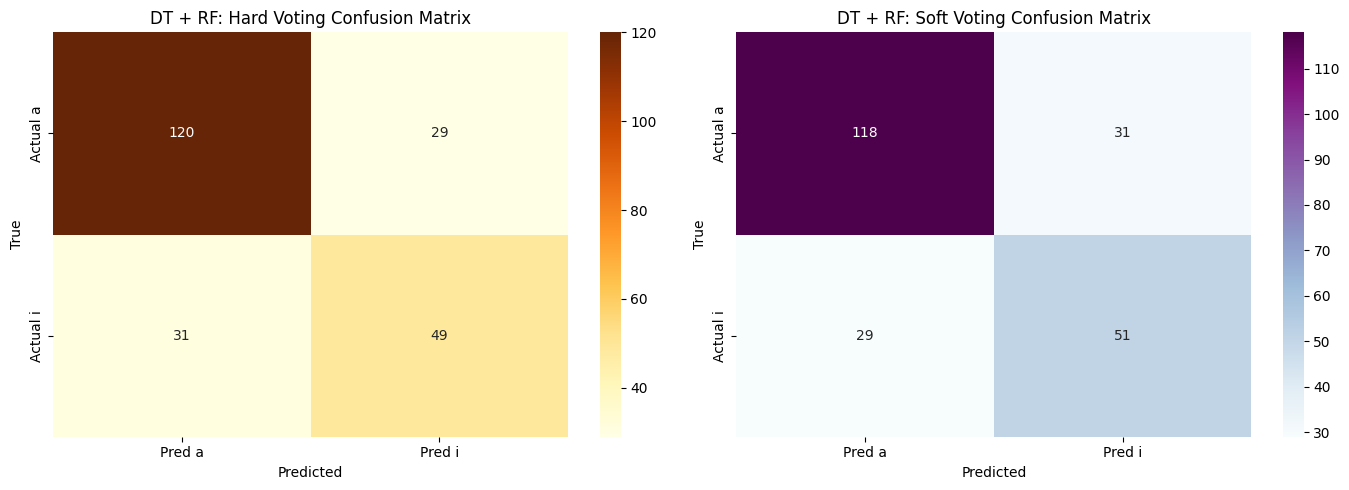

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 1. Initialize our tree-based base models
base_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
base_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. Build the tree-only Hard and Soft Voting ensembles
voting_hard_trees = VotingClassifier(estimators=[('dt', base_dt), ('rf', base_rf)], voting='hard')
voting_soft_trees = VotingClassifier(estimators=[('dt', base_dt), ('rf', base_rf)], voting='soft')

# 3. Fit both new models
voting_hard_trees.fit(X_train, y_train)
voting_soft_trees.fit(X_train, y_train)

# 4. Generate predictions
preds_hard_trees = voting_hard_trees.predict(X_test)
preds_soft_trees = voting_soft_trees.predict(X_test)

# --- Print Reports ---
print("=== NEW: HARD VOTING (DT + RF) PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(y_test, preds_hard_trees):.4f} | F1-Score: {f1_score(y_test, preds_hard_trees):.4f}")
print(classification_report(y_test, preds_hard_trees, target_names=['Vowel_0 (a)', 'Vowel_1 (i)']))

print("\n=== NEW: SOFT VOTING (DT + RF) PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(y_test, preds_soft_trees):.4f} | F1-Score: {f1_score(y_test, preds_soft_trees):.4f}")
print(classification_report(y_test, preds_soft_trees, target_names=['Vowel_0 (a)', 'Vowel_1 (i)']))

# 5. Plot Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hard Voting CM
cm_hard_trees = confusion_matrix(y_test, preds_hard_trees)
sns.heatmap(cm_hard_trees, annot=True, fmt='d', cmap='YlOrBr', ax=axes[0],
            xticklabels=['Pred a', 'Pred i'], yticklabels=['Actual a', 'Actual i'])
axes[0].set_title('DT + RF: Hard Voting Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Soft Voting CM
cm_soft_trees = confusion_matrix(y_test, preds_soft_trees)
sns.heatmap(cm_soft_trees, annot=True, fmt='d', cmap='BuPu', ax=axes[1],
            xticklabels=['Pred a', 'Pred i'], yticklabels=['Actual a', 'Actual i'])
axes[1].set_title('DT + RF: Soft Voting Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()